<a href="https://colab.research.google.com/github/maazali04/Machine-Learning-Algorithms/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression
- Linear regression is a fundamental statistical and supervised machine learning algorithm used to model and quantify the relationship between a continuous dependent variable (the target outcome) and one or more independent variables (the input features or predictors).

## Types
1. Simple Linear Regression
2. Multiple Linear Regression
3. Polynomial Linear Regression


## Simple Linear Regression
- Simple linear regression is a statistical method that predicts the value of one target variable based on the value of a single predictor variable.

### Using SKLearn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


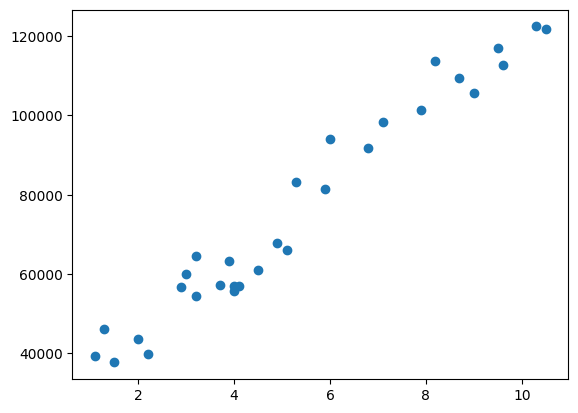

In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:,-1]

plt.scatter(X,y)
plt.show()

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
r2_score(y_test, y_pred) * 100

90.24461774180497

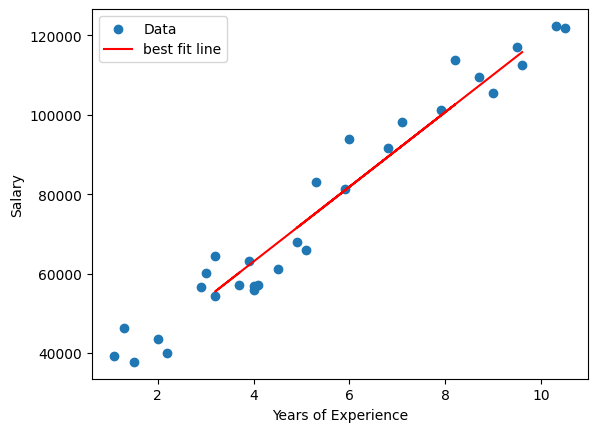

In [ ]:
plt.scatter(X,y, label="Data")
plt.plot(X_test, y_pred, color="red", label="best fit line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend();

In [ ]:
m = model.coef_
b = model.intercept_
m,b

(array([9423.81532303]), np.float64(25321.583011776813))

### From Scratch

- Line Equation:  $$y = m*x + b$$
Where, y = y point, x = x point, m = slope and b = y-intercept.

- To find m, and b we have two methods:
  1. Closed-Form solution (exact mathematical answer that can be calculated in a finite number of standard operations) : Ordinary Least Squares (OLS)
  2. Non-closed-form solution (cannot be expressed this way and requires guessing, checking, and refining the answer over multiple steps). : Gradient Descent

#### OLS
  - $$b = \bar y - m \bar x$$
  - $$m = \frac {\sum_{i=1}^{n} (x_i - \bar x ) (y_i - \bar y )}{ \sum_{i=1}^{n}  (x_i - \bar x)^2 } $$  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


Point 1: Experience = 1.1 yrs | Actual Salary = $39,343.00 | Predicted = $10.00 | Error = $39,333.00
Point 2: Experience = 1.3 yrs | Actual Salary = $46,205.00 | Predicted = $10.00 | Error = $46,195.00
Point 3: Experience = 1.5 yrs | Actual Salary = $37,731.00 | Predicted = $10.00 | Error = $37,721.00
Point 4: Experience = 2.0 yrs | Actual Salary = $43,525.00 | Predicted = $10.00 | Error = $43,515.00
Point 5: Experience = 2.2 yrs | Actual Salary = $39,891.00 | Predicted = $10.00 | Error = $39,881.00
Point 6: Experience = 2.9 yrs | Actual Salary = $56,642.00 | Predicted = $10.00 | Error = $56,632.00
Point 7: Experience = 3.0 yrs | Actual Salary = $60,150.00 | Predicted = $10.00 | Error = $60,140.00
Point 8: Experience = 3.2 yrs | Actual Salary = $54,445.00 | Predicted = $10.00 | Error = $54,435.00
Point 9: Experience = 3.2 yrs | Actual Salary = $64,445.00 | Predicted = $10.00 | Error = $64,435.00
Point 10: Experience = 3.7 yrs | Actual Salary = $57,189.00 | Predicted = $10.00 | Error = 

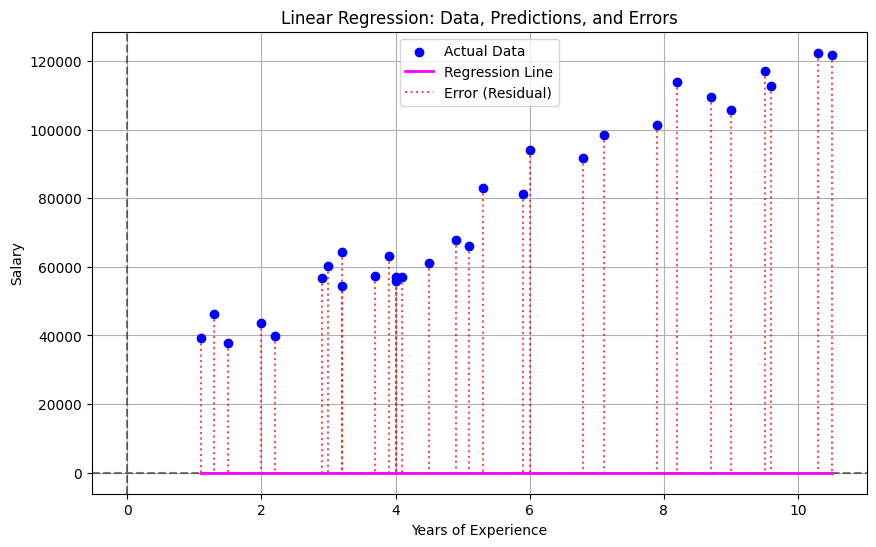

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = df["YearsExperience"]
y = df["Salary"]

def plot_data():
    plt.scatter(x, y, color="blue", zorder=3, label="Actual Data")
    plt.xlabel("Years of Experience")
    plt.ylabel("Salary")
    plt.grid(True, zorder=1)
    plt.axvline(0, c="k", linestyle="--", alpha=0.5)
    plt.axhline(0, c="k", linestyle="--", alpha=0.5)

m = 0
b = 10

y_pred = m * x + b

plt.figure(figsize=(10, 6))

plot_data()
plt.plot(x, y_pred, color="magenta", linewidth=2, zorder=4, label="Regression Line")

total_squared_error = 0
for i in range(len(x)):
    actual_y = y.iloc[i]
    pred_y = y_pred.iloc[i]
    error = actual_y - pred_y

    # Track the squared error for the final score calculation
    total_squared_error += error ** 2

    # Print individual status
    print(f"Point {i+1}: Experience = {x.iloc[i]:.1f} yrs | Actual Salary = ${actual_y:,.2f} | Predicted = ${pred_y:,.2f} | Error = ${error:,.2f}")

    # Draw vertical error lines on the graph
    plt.plot([x.iloc[i], x.iloc[i]], [actual_y, pred_y],
             color="red", linestyle=":", alpha=0.7, zorder=2,
             label="Error (Residual)" if i == 0 else "")


mean_squared_error = total_squared_error / len(x)

print("\n--- Final Model Error Summary ---")
print(f"Total Squared Error: {total_squared_error:,.2f}")
print(f"Final Mean Squared Error (MSE): {mean_squared_error:,.2f}")
plt.legend()
plt.title("Linear Regression: Data, Predictions, and Errors")
plt.show()


As we know that
$$ E = \sum_{i=1}^{n} (y_i - \hat y_i)^2 \implies E(m,b) =  \sum_{i=1}^{n} (y_i - mx_i - b)^2 $$

Let's suppose b = 0:
$$
E(m) =  \sum_{i=1}^{n} (y_i - mx_i)^2
$$

--- Sampling Slopes and Errors ---
Slope (m) = 0.00 | Mean Squared Error (MSE) = 6502955270.73
Slope (m) = 252.53 | Mean Squared Error (MSE) = 6264141563.12
Slope (m) = 505.05 | Mean Squared Error (MSE) = 6029921349.36
Slope (m) = 757.58 | Mean Squared Error (MSE) = 5800294629.47
Slope (m) = 1010.10 | Mean Squared Error (MSE) = 5575261403.44
Slope (m) = 1262.63 | Mean Squared Error (MSE) = 5354821671.27
Slope (m) = 1515.15 | Mean Squared Error (MSE) = 5138975432.96
Slope (m) = 1767.68 | Mean Squared Error (MSE) = 4927722688.51
Slope (m) = 2020.20 | Mean Squared Error (MSE) = 4721063437.93
Slope (m) = 2272.73 | Mean Squared Error (MSE) = 4518997681.20
Slope (m) = 2525.25 | Mean Squared Error (MSE) = 4321525418.34
Slope (m) = 2777.78 | Mean Squared Error (MSE) = 4128646649.33
Slope (m) = 3030.30 | Mean Squared Error (MSE) = 3940361374.19
Slope (m) = 3282.83 | Mean Squared Error (MSE) = 3756669592.91
Slope (m) = 3535.35 | Mean Squared Error (MSE) = 3577571305.49
Slope (m) = 3787.88 | Mean

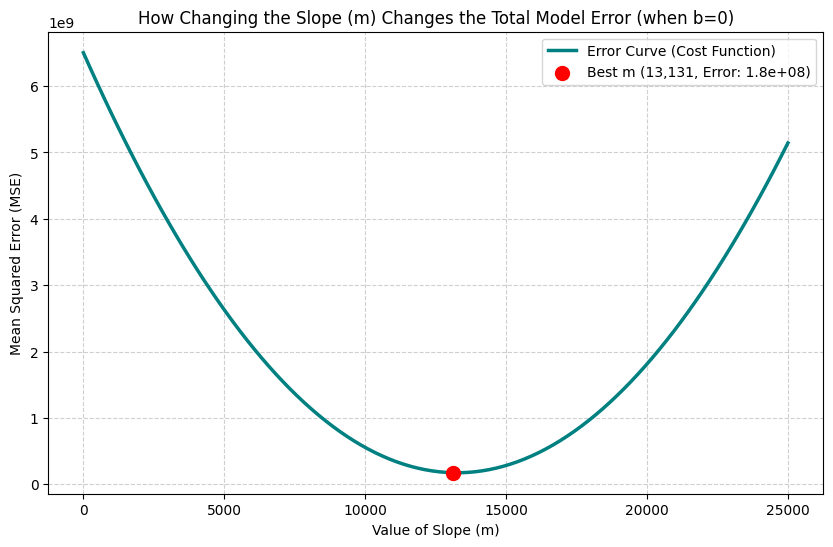

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = df["YearsExperience"]
y = df["Salary"]

b = 0

m_values = np.linspace(0, 25000, 100)
mse_values = []

print("--- Sampling Slopes and Errors ---")
for m in m_values:
    y_pred = m * x + b
    mse = np.mean((y - y_pred) ** 2)
    print(f"Slope (m) = {m:.2f} | Mean Squared Error (MSE) = {mse:.2f}")
    mse_values.append(mse)

best_index = np.argmin(mse_values)
best_m = m_values[best_index]
lowest_error = mse_values[best_index]

print(f"Lowest error achieved at slope m = {best_m:,.2f}")
print(f"Minimum Mean Squared Error = {lowest_error:,.2f}\n")

plt.figure(figsize=(10, 6))

plt.plot(m_values, mse_values, color="teal", linewidth=2.5, label="Error Curve (Cost Function)")

plt.scatter(best_m, lowest_error, color="red", s=100, zorder=5,
            label=f"Best m ({best_m:,.0f}, Error: {lowest_error:,.1e})")

plt.xlabel("Value of Slope (m)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("How Changing the Slope (m) Changes the Total Model Error (when b=0)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


Let's suppose m = 1:
$$
E(b) =  \sum_{i=1}^{n} (y_i - x_i - b)^2
$$

--- Sampling y-intercept and Errors ---
Slope (m) = 1.00 | Mean Squared Error (MSE) = 3225820825.56
Slope (m) = 1.00 | Mean Squared Error (MSE) = 3125841762.61
Slope (m) = 1.00 | Mean Squared Error (MSE) = 3027903307.76
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2932005461.01
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2838148222.36
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2746331591.81
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2656555569.36
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2568820155.02
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2483125348.78
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2399471150.63
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2317857560.59
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2238284578.65
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2160752204.81
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2085260439.07
Slope (m) = 1.00 | Mean Squared Error (MSE) = 2011809281.44
Slope (m) = 1.00 | Mean Squared Error (MSE) = 1940398731.90


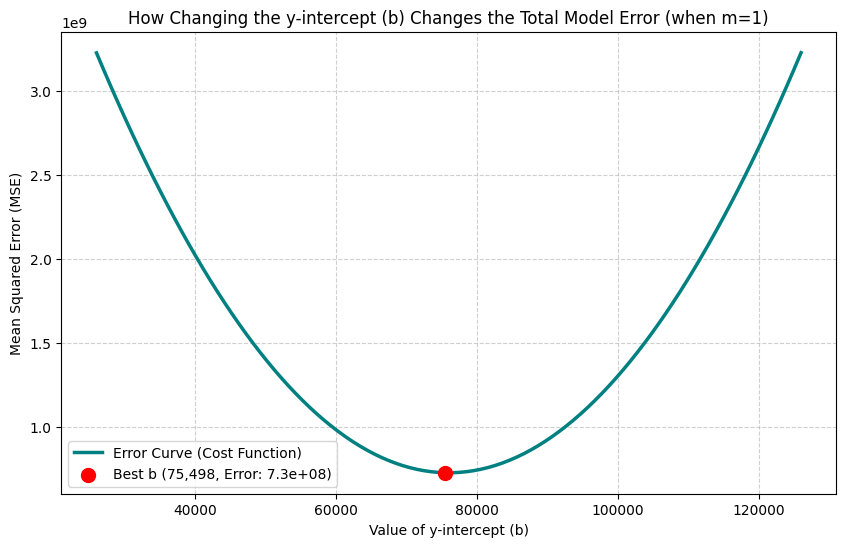

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = df["YearsExperience"]
y = df["Salary"]

m = 1

avg_salary = y.mean()
b_values = np.linspace(avg_salary - 50000, avg_salary + 50000, 100)
mse_values = []

print("--- Sampling y-intercept and Errors ---")
for b in b_values:
    y_pred = m * x + b
    mse = np.mean((y - y_pred) ** 2)
    print(f"Slope (m) = {m:.2f} | Mean Squared Error (MSE) = {mse:.2f}")
    mse_values.append(mse)

best_index = np.argmin(mse_values)
best_b = b_values[best_index]
lowest_error = mse_values[best_index]

print(f"Lowest error achieved at slope m = {best_b:,.2f}")
print(f"Minimum Mean Squared Error = {lowest_error:,.2f}\n")

plt.figure(figsize=(10, 6))

plt.plot(b_values, mse_values, color="teal", linewidth=2.5, label="Error Curve (Cost Function)")

plt.scatter(best_b, lowest_error, color="red", s=100, zorder=5,
            label=f"Best b ({best_b:,.0f}, Error: {lowest_error:,.1e})")

plt.xlabel("Value of y-intercept (b)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("How Changing the y-intercept (b) Changes the Total Model Error (when m=1)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


$$ E(m,b) =  \sum_{i=1}^{n} (y_i - mx_i - b)^2 $$

Let's find: $ \frac {\delta E} {\delta b}$ and $\frac {\delta E} {\delta m} $

To find $ \frac {\delta E} {\delta b}$:

$$\frac {\delta E} {\delta b} = \frac {\delta} {\delta b} \sum_{i=1}^{n} (y_i - mx_i - b)^2$$
$$ \frac {\delta E} {\delta b} = \sum_{i=1}^{n} -2 (y_i - mx_i - b)$$

To find the lowest error w.r.t to b: $\frac {\delta E} {\delta b} = 0  $
$$ \sum_{i=1}^{n} -2 (y_i - mx_i - b) = 0  $$
$$ \sum_{i=1}^{n} (y_i - mx_i - b) = 0  $$
$$ \sum_{i=1}^{n} (y_i)  - \sum_{i=1}^{n}(mx_i) - \sum_{i=1}^{n} (b) = 0  $$
Divide both side by n:
$$ \frac {\sum_{i=1}^{n} (y_i)}{n}  - \frac {\sum_{i=1}^{n}(mx_i)}{n} - \frac {\sum_{i=1}^{n} (b)}{n} = \frac {0}{n}  $$
$$\bar y - m \bar x - \frac {bn}{n} = 0 \implies \bar y - m \bar x - b = 0$$
$$b = \bar y - m \bar x$$



To find $\frac {\delta E} {\delta m} $:
$$\frac {\delta E} {\delta m} = \frac {\delta} {\delta m} \sum_{i=1}^{n} (y_i - mx_i - b)^2 $$

Put the value of b:
$$\frac {\delta E} {\delta m} = \frac {\delta} {\delta m} \sum_{i=1}^{n} (y_i - mx_i - \bar y + m \bar x)^2 $$
$$\frac {\delta E} {\delta m} =  2 \sum_{i=1}^{n} (y_i - mx_i - \bar y + m \bar x) (-x_i + \bar x) $$
$$\frac {\delta E} {\delta m} =  -2 \sum_{i=1}^{n} (y_i - mx_i - \bar y + m \bar x) (x_i - \bar x) $$

To find the lowest error w.r.t to m: $\frac {\delta E} {\delta m} = 0  $

$$-2 \sum_{i=1}^{n} (y_i - mx_i - \bar y + m \bar x) (x_i - \bar x) = 0$$
$$ \sum_{i=1}^{n} (y_i - mx_i - \bar y + m \bar x) (x_i - \bar x) = 0$$
$$ \sum_{i=1}^{n} [(y_i - \bar y) - m (x_i - \bar x)] (x_i - \bar x) = 0$$
$$ \sum_{i=1}^{n} [(y_i - \bar y)(x_i - \bar x) - m (x_i - \bar x)^2]  = 0$$
$$ \sum_{i=1}^{n} (y_i - \bar y)(x_i - \bar x)  =   m (x_i - \bar x)^2 $$

$$m = \frac {\sum_{i=1}^{n} (x_i - \bar x) (y_i - \bar y)}{\sum_{i=1}^n (x_i - \bar x)^2}$$

Let's code it!!!

In [ ]:
class LinearRegressionModel:

  def __init__(self):
    self.m = 0
    self.b = 0

  def fit(self,x_train,y_train):
    n = x_train.shape[0]
    mean_x = np.mean(x_train)
    mean_y = np.mean(y_train)

    num = 0
    den = 0
    for i in range(n):
      x_val = x_train.iloc[i]
      y_val = y_train.iloc[i]

      num += (x_val - mean_x) * (y_val - mean_y)
      den += (x_val - mean_x)**2

    self.m = num / den
    self.b = mean_y - (self.m * mean_x)
    print(self.m)
    print(self.b)

  def predict(self, x_test):
    return (self.m * x_test) + self.b

In [ ]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
x = df["YearsExperience"]
y = df["Salary"]

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
model = LinearRegressionModel()
model.fit(x_train,y_train)

9423.815323030976
25321.583011776813


In [ ]:
y_pred = model.predict(x_test)
r2_score(y_test, y_pred) * 100

90.24461774180497

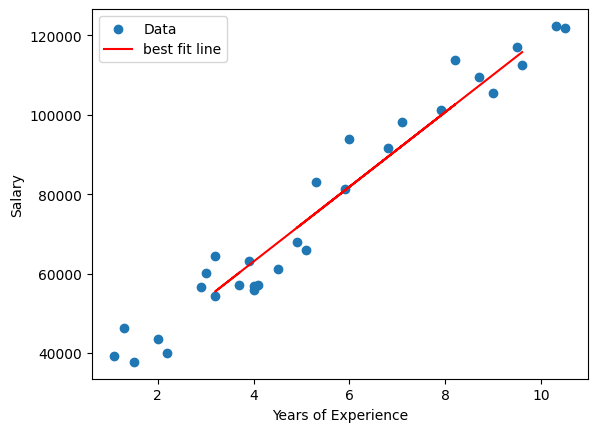

In [ ]:
plt.scatter(x,y, label="Data")
plt.plot(x_test, y_pred, color="red", label="best fit line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend();

## Regression Metrics

* MAE
* MSE
* RMSE
* R2 Score
* Adjusted R2 score

### MAE
- Stands for Mean Absolute Error
$$ \frac {\sum^n_{i = 1} | y - \bar y|}{n} $$

**Advantages**
- Robust to Outliers
- Direct Interpretability (Same Unit)
- Steady Penalization

**Disadvantages**
- Differentiability Issue at Zero
- No Closed-Form Solution
- Indifference to Large Errors

### MSE
- Stands for Mean Squared Error
$$ \frac {\sum^n_{i = 1} ( y - \bar y)^2} {n} $$

**Advantages**
- Mathematical Convenience (differentiable everywhere)
- Has a Closed-Form Solution
- Strongly Penalizes Large Errors

**Disadvantages**
- Highly Sensitive to Outliers
- Poor Interpretability
- Asymmetric Focus

### RMSE
- Stands for Root Mean Squared Error

$$ \sqrt {\frac {\sum^n_{i = 1} ( y - \bar y)^2} {n}} $$

**Advantages**
- Excellent Human Interpretability
- Retains the Calculus Benefits of MSE
- Safeguards Against Large Failures

**Disadvantages**
- Still Vulnerable to Outliers
- Varying Scores with Sample Size
- More Complex to Calculate

Pro Tip: MAE, MSE, and RMSE are all loss functions.

### R2 Score (coefficient of determination)
- This formula determines the proportion of variance in the dependent variable that can be explained by the independent variables in a regression model.
- In simple term, R2 Score measure that how much your predicted line is better than mean line.

$$  R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$
$$  R^2 = 1 - \frac{\text {total error of predicted line}}{\text {total error of mean line}}$$

Residual Sum of Squares = $ SS_{res} = \sum^n_{i=1} (y_i - \hat y_i)^2 $

Total Sum of Squares = $ SS_{tot} = \sum^n_{i=1} (y_i - \bar y)^2 $

- If R2 Score = 0: predicted line is above the mean line. (model is not learning anything).
- If R2 score = 1: predicted line passess through each data points (model crame the entire data points).
- If R2 score = -1: mean line is predicting better than predicted line. (predicted line is far more away than the actual data points).

### Adjusted R2 Score
$$  R^2_{adj} = 1 - \frac {(1-R^2) (n-1)}{n-p-1} $$
- $R^2$ represents r2 score.
- n represents number of rows.
- p represents total number of columns.

Cases:
- If the feature is helpful, then adjusted r2 score increases.
- If the feature is noise, then adjusted r2 score decreases.

Note: If we add irrelevant cols to the dataset then R2 score either increases or remain the same. So to solve this problem, we introduce the adjusted R2 score.

## Multiple Linear Regression
- Here we have more than 1 features and one label column.
- For two variables:
$$ y = mx + b \implies y = mx_1 + nx_2 + b $$
$$ y = b_o + b_1x_1+b_2x_2$$

- For N variables:
$$y = b_0 + b_1x_1 + b_2x_2 + b_3x_3 + ... b_nx_n$$
$$y = b_0 + \sum_{i=1}^n b_ix_i$$
Here $b_0$ represents offeset and $b_i$ represents weight of that col.

Pro tip:
- 2D have one slope (line).
- 3D have two slopes (plane).
- 4D have three slopes (4D hyperplane).
- 5D have four slopes (5D hyperplane).
- 100D have 99 slopes (100 hyperplne).

### Using SKLearn

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/harimittapalli/Mulitple-Linear-Reggression/master/50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [ ]:
x = df.iloc[:, :-1]
y = df["Profit"]

x = pd.get_dummies(x, columns=['State'], drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"MSE : {mean_squared_error(y_test, y_pred)}")
print(f"RMSE :{np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MAE : 6961.477813252376
MSE : 82010363.04430099
RMSE :9055.957323458464
R2 Score: 0.8987266414328637


In [ ]:
print(model.coef_)
print(model.intercept_)

[ 8.05630064e-01 -6.87878823e-02  2.98554429e-02  9.38793006e+02
  6.98775997e+00]
54028.03959364581


### From Scratch

Let assume a dataset of 100 rows, 3 input cols and 1 label col.
$$ y = b_0 + b_1 x_1 + b_2x_2 + b_3x_3 $$
$$ \hat Y =
\begin{bmatrix}
\hat y_1 \\
\hat y_2 \\
... \\
\hat y_{100} \\
\end{bmatrix}
 = \begin{bmatrix} b_0 & b_1x_{11} & b_2x_{12} &  b_3x_{13}  \\ b_0& b_1x_{21} & b_2x_{22} &  b_3x_{23}  \\ ... & ... & ... & ... \\ b_0 & b_1x_{1001}  & b_2x_{1002} & b_3x_{1003} \end{bmatrix}$$

&nbsp;

Now let's assume a dataset of n rows, m cols and 1 label col.
$$ y_i = b_0 + b_1 x_1 + b_2x_2 + b_3x_3 + b_mx_m $$
$$ \hat Y =
\begin{bmatrix}
\hat y_1 \\
\hat y_2 \\
... \\
\hat y_{n} \\
\end{bmatrix}
 = \begin{bmatrix} b_0 & b_1x_{11} & b_2x_{12} & ... &  b_mx_{1m}  \\ b_0& b_1x_{21} & b_2x_{22} & ... &  b_mx_{2m}  \\ ... & ... & ... & ... & ... \\ b_0 & b_1x_{n1}  & b_2x_{n2} & ... &  b_mx_{nm} \end{bmatrix}$$

 &nbsp;

$$ \hat Y =
\begin{bmatrix}
\hat y_1 \\
\hat y_2 \\
... \\
\hat y_{n} \\
\end{bmatrix}
 = \begin{bmatrix} 1 & x_{11} & x_{12} & ... &  x_{1m}  \\ 1 & x_{21} & x_{22} & ... &  x_{2m}  \\ ... & ... & ... & ... & ... \\ 1 & x_{n1}  & x_{n2} & ... &  x_{nm} \end{bmatrix} \begin{bmatrix} b_0 \\ b_1 \\ b_2 \\ ... \\ b_n \end{bmatrix}$$

 $$ \hat Y = X b $$


Where:
* $\hat y $ is the vector of predicted values ($n \times 1$)
* $X $ is your dataset with a column of 1s added at the front ($n \times (m+1)$)
* $b$ is the vector of your $y$-intercept ($b_0$) and slopes ($b_i$) ($(m+1) \times 1$)

&nbsp;

Now, let's find some new matrices.

$$ Y = \begin{bmatrix} y_1 \\ y_2 \\ ... \\ y_n \end{bmatrix} $$

&nbsp;

$$ e = Y - \hat Y = \begin{bmatrix} y_1 \\ y_2 \\ ... \\ y_n  \end{bmatrix} - \begin{bmatrix} \hat y_1 \\ \hat y_2 \\ ... \\ \hat y_n \end{bmatrix} $$
$$ e =  \begin{bmatrix} y_1 - \hat y_1 \\ y_2 - \hat y_2 \\ ... \\ y_n - \hat y_n \end{bmatrix}  $$

&nbsp;
Now to find Sum of Squared Errors (SSE):

$$ E = e^T e = \begin{bmatrix} (y_1 - \hat y_1) & (y_2 - \hat y_2) & ... & (y_n - \hat y_n) \end{bmatrix} \begin{bmatrix} (y_1-\hat y_1) \\ (y_2-\hat y_2)  \\ ... \\ (y_n - \hat y_n)\end{bmatrix}$$

$$ E = \begin{bmatrix} (y_1 - \hat y_1)^2 + (y_2 - \hat y_2)^2 + ... + (y_n - \hat y_n)^2 \end{bmatrix}  = \sum_{i=1}^n (y_i - \hat y_i)^2$$

&nbsp;

$$ E = e ^ T e = (y-\hat y)^T (y - \hat y) = (y^T-\hat y^T) (y - \hat y ) $$
Put the value value of $\hat y$
$$ E = [y^T - (Xb)^T] (y - Xb)$$
$$ E = y^Ty - y^T(Xb) - (Xb)^Ty + (Xb)^T(Xb) $$

&nbsp;

Here,   $y^T(Xb) = (Xb)^Ty.$

$$ E = y^Ty - 2 y^T(Xb)  + b^T X^T(Xb)  $$

Let's find $\frac {\partial E} {\partial b}$
$$ \frac {\partial E} {\partial b} = \frac {\partial} {\partial b} (y^Ty - 2 y^T(Xb)  + b^T X^T(Xb)) $$
$$ = 0 - 2y^TX + 2 X^TXB^T$$

Now $\frac {\partial E} {\partial b} = 0$
$$- 2y^TX + 2 X^TXB^T = 0$$
$$ B^T = y^T X (X^T X)^{-1} $$
Taking Transpose on both side:
$$ [B^T]^T = [y^T X (X^T X)^{-1}]^T $$
$$ B = [(X^T X)^{-1}]^T [y^T X]^T  $$
$$ B = (X^T X)^{-1} (X^T y)   $$

In [ ]:
class LinearRegressionModel2:

  def __init__(self):
    self.coef_ = None
    self.intercept_ = None

  def fit(self, x_train, y_train):
    x_train_copy = x_train.copy()
    x_train_copy.insert(0,"One",1)
    x_train_copy = x_train_copy.astype(float)
    coefficients = np.linalg.inv(x_train_copy.T.dot(x_train_copy)).dot(x_train_copy.T.dot(y_train))
    self.intercept_ = coefficients[0]
    self.coef_ = coefficients[1:]
    print(f"Coefficients: {self.coef_}")
    print(f"Intercept: {self.intercept_}")

  def predict(self, x_test):
    y_pred = x_test.dot(self.coef_) + self.intercept_
    return y_pred



In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/harimittapalli/Mulitple-Linear-Reggression/master/50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [ ]:
x = df.iloc[:, :-1]
y = df["Profit"]

x = pd.get_dummies(x, columns=['State'], drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
x_train.head()

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
12,93863.75,127320.38,249839.44,True,False
4,142107.34,91391.77,366168.42,True,False
37,44069.95,51283.14,197029.42,False,False
8,120542.52,148718.95,311613.29,False,True
3,144372.41,118671.85,383199.62,False,True


In [ ]:
x_train.insert(0,"One",1) # at index 0 create col "One" with value 1
x_train.head()

,One,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
12,1,93863.75,127320.38,249839.44,True,False
4,1,142107.34,91391.77,366168.42,True,False
37,1,44069.95,51283.14,197029.42,False,False
8,1,120542.52,148718.95,311613.29,False,True
3,1,144372.41,118671.85,383199.62,False,True


In [ ]:
model = LinearRegressionModel2()
model.fit(x_train, y_train)

Coefficients: [ 8.05630064e-01 -6.87878823e-02  2.98554429e-02  9.38793006e+02
  6.98775997e+00]
Intercept: 54028.039594059446


In [ ]:
y_pred = model.predict(x_test)

In [ ]:
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"MSE : {mean_squared_error(y_test, y_pred)}")
print(f"RMSE :{np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MAE : 6961.477813275638
MSE : 82010363.04501499
RMSE :9055.957323497885
R2 Score: 0.898726641431982


## Assumption of Linear Regression

- Linear Relationship between inputs and output.
- No Multicollinearity.
- Normality of Residual.
- Homoscedesity.
- No AutoCorrelation of Errors.

## Gradient Descent

$$ E(m,b) =  \sum_{i=1}^{n} (y_i - mx_i - b)^2 $$
Let's suppose m is constant then:
$$ E(b) =  \sum_{i=1}^{n} (y_i - mx_i - b)^2 $$

As above equation clearly demonstrates that E is directly proportional to $b^2$ so its graph will be parabolic.

To find the minimum point of that loss vs b graph:
$$b_{new} = b_{old} - slope$$

This will give us drastic changes so instead of it we use:

$$b_{new} = b_{old} - \eta   \text{ slope}$$
Here $\eta$ is learning rate.

$$ \text{slope} = \frac {\partial E} {\partial B} = -2 \sum_{i=1}^n (y_i - mx_i - b) $$

Stopping Condition:
- If $b_{old}$ - $b_{new}$ < 0.001
- If number of iterations (epochs) ends.

Now let's suppose b is constant:
$$ E(m) =  \sum_{i=1}^{n} (y_i - mx_i - b)^2 $$

The graph of it will also be parabolic (loss vs m).
$$ m_{new} = m_{old} - \eta \text{slope}$$
$$ \text{slope} = \frac {\partial E} {\partial m} = -2 \sum_{i=1}^n x_i (y_i - mx_i - b) $$

In [ ]:
import numpy as np
import plotly.graph_objects as go

class GDRegressor:
  def __init__(self):
    self.coef_ = 0.0
    self.intercept_ = 0.0
    self.loss = []

  def fit(self, x, y, epochs=100, learning_rate=0.01):
    for i in range(epochs):
      y_pred = self.coef_ * x + self.intercept_
      slope_b = -2 * np.sum(y - y_pred)
      slope_m = -2 * np.sum(x * (y - y_pred))
      self.loss.append(np.sum((y - y_pred)**2))
      self.intercept_ = self.intercept_ - learning_rate * slope_b
      self.coef_ = self.coef_ - learning_rate * slope_m
      print(f"b: {self.intercept_}, m: {self.coef_}")
    print(f"Coefficients: {self.coef_}")
    print(f"Intercept: {self.intercept_}")

  def predict(self,x):
    return self.coef_ * x + self.intercept_

  def plot_loss(self):
    fig = go.Figure(data=go.Scatter(x=list(range(len(self.loss))), y=self.loss))
    fig.update_layout(title="Loss vs Epochs", xaxis_title="Epochs", yaxis_title="Loss")
    fig.show()

In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
from sklearn.model_selection import train_test_split


x = df["YearsExperience"]
y = df["Salary"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
model = GDRegressor()

In [ ]:
model.fit(x_train, y_train, epochs=1100, learning_rate=0.0007)

b: 2493.3762, m: 15562.848979999999
b: 2190.3703824660006, m: 12278.72698579996
b: 2469.96802399021, m: 12932.857068690175
b: 2626.1563113114416, m: 12764.353289855471
b: 2806.4668808295687, m: 12767.982376272459
b: 2980.0864654494053, m: 12735.88976554067
b: 3153.4661740765664, m: 12711.503964781203
b: 3325.2707695662302, m: 12685.748872914945
b: 3495.79184315973, m: 12660.519037731627
b: 3664.9809689529407, m: 12635.416746966674
b: 3832.860669399831, m: 12610.5232615754
b: 3999.4385464154043, m: 12585.819777175677
b: 4164.725224094126, m: 12561.308411798484
b: 4328.730600388088, m: 12536.986925856914
b: 4491.464631038188, m: 12512.854004201807
b: 4652.937166502929, m: 12488.908152348702
b: 4813.157986754052, m: 12465.147926999796
b: 4972.136794723052, m: 12441.571887770959
b: 5129.8832183818795, m: 12418.178607172686
b: 5286.406811014049, m: 12394.966668419935
b: 5441.717051858383, m: 12371.934665785899
b: 5595.823346669458, m: 12349.081204425018
b: 5748.735028290084, m: 12326.404900

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_pred, y_test) * 100

89.61892643163569

In [ ]:
model.plot_loss()

### Types of GD
1. Batch GD
2. Stochastic GD
3. Mini-Batch GD


Note:
- Batch GD method looks at the entire dataset to calculate a single average slope and intercept before taking one single step.
- Stochastic Gradient Descent picks one single random row, calculates the slope and intercept based only on that row, and updates the parameters immediately. It repeats this for every single row in your data.
- Mini-Batch Gradient Descent : you split your dataset into small batches (standard industry choices are batch sizes of 32, 64, or 128 rows). The model calculates the slope and intercept for that small group, updates the parameters, and then moves to the next batch.



### Batch GD

| x1 | x2 | y |
|---|---|---|
|8.1|93|3.2|
|7.5|95|3.5|

Steps of Batch GD:
1. Random Values:
  - $b_0$ = 0, and $b_1$, $b_2$  = 1.

2. Finding $b_0$ and $b_1$:
  - $b_0$ =  $b_0$ - $\eta$ slope : slope = $\frac {\partial L}{\partial b_0}$
  - $b_1$ =  $b_1$ - $\eta$ slope : slope = $\frac {\partial L}{\partial b_1}$
  - $b_2$ =  $b_2$ - $\eta$ slope : : slope = $\frac {\partial L}{\partial b_2}$

3. Finding slopes:
  $$L = \frac {1}{n} \sum_{i=1}^n (y_i - \hat y_i)^2$$
  - For 2 rows:
  $$L = \frac {1} {2} [(y_1 - \hat y_1)^2+(y_2 - \hat y_2)^2]$$
  - $\hat y$ = $b_0 + b_1x_1 + b_2x_2$
  - $\hat y_1$ = $b_0 + b_1x_{11} + b_2x_{12}$
  - $\hat y_2$ = $b_0 + b_1x_{21} + b_2x_{22}$

  &nbsp;
  $$L = \frac {1} {2} [(y_1 - b_0 - b_1x_{11} - b_2x_{12})^2+(y_2 - b_0 - b_1x_{21} - b_2x_{22})^2]$$

&nbsp;
  -  To find $\frac {\partial L}{\partial b_0}$:
   $$ \frac {\partial L}{\partial b_0} = \frac {1} {2} [2 (y_1 - b_0 - b_1x_{11} - b_2x_{12}) (-1) + 2 (y_2 - b_0 - b_1x_{21} - b_2x_{22}) (-1)] $$
   $$ \frac {\partial L}{\partial b_0} = \frac {-2} {2} [ (y_1 -\hat y_1) +  (y_2 - \hat y_2)] $$

   - For n rows:
   $$ \frac {\partial L}{\partial b_0} = \frac {-2} {n} [ (y_1 -\hat y_1) +  (y_2 - \hat y_2) + (y_3 - \hat y_3)+ ... + (y_n - \hat y_n)] $$
   $$ \frac {\partial L}{\partial b_0} = \frac {-2} {n} \sum_{i=1}^n (y_i - \hat y_i) $$

&nbsp;
  -  To find $\frac {\partial L}{\partial b_1}$:
  $$ \frac {\partial L}{\partial b_1} = \frac {1} {2} [2 (y_1 - b_0 - b_1x_{11} - b_2x_{12}) (-1) + 2 (y_2 - b_0 - b_1x_{21} - b_2x_{22}) (-1)] $$

   $$ \frac {\partial L}{\partial b_1} = \frac {-2} {2} [ (y_1 -\hat y_1) (x_{11}) +  (y_2 - \hat y_2) (x_{21})] $$

  $$ \frac {\partial L}{\partial b_1} = \frac {-2} {n} \sum_{i=1}^n (y_i - \hat y_i) (x_{i1}) $$

&nbsp;
  -  To find $\frac {\partial L}{\partial b_2}$:
  $$ \frac {\partial L}{\partial b_2} = \frac {1} {2} [2 (y_1 - b_0 - b_1x_{11} - b_2x_{12}) (-1) + 2 (y_2 - b_0 - b_1x_{21} - b_2x_{22}) (-1)] $$

   $$ \frac {\partial L}{\partial b_2} = \frac {-2} {2} [ (y_1 -\hat y_1) (x_{12}) +  (y_2 - \hat y_2) (x_{22})] $$

  $$ \frac {\partial L}{\partial b_1} = \frac {-2} {n} \sum_{i=1}^n (y_i - \hat y_i) (x_{i2}) $$




&nbsp;
 - Generally:
  $$\frac {\partial L}{\partial b_m} = \frac {-2}{n} \sum_{i=1}^n (y_i - \hat y_i) (x_{im}) $$



##### Using sklearn

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import pandas as pd

In [ ]:
x,y = load_diabetes(return_X_y=True)
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
reg = LinearRegression()
reg.fit(x_train, y_train)
y_pred = reg.predict(x_test)
r2_score(y_test, y_pred) * 100

45.26027629719195

In [ ]:
print(reg.coef_)
print(reg.intercept_)

[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
151.34560453985995


##### From Scratch

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
class GDRegressor2:
  def __init__(self):
    self.coef_ = 0.0
    self.intercept_ = 0.0
    self.loss = []

  def fit(self, x_train, y_train, epochs=100, learning_rate=0.01):
    self.coef_ = np.ones(x_train.shape[1])
    for i in range(epochs):
      y_hat = np.dot(x_train,self.coef_ ) + self.intercept_
      slope_b = -2 * np.mean(y_train - y_hat)
      self.intercept_ = self.intercept_ - learning_rate * slope_b
      slope_m = -2 * np.dot((y_train - y_hat), x_train) / x_train.shape[0]
      self.coef_ = self.coef_ - (learning_rate * slope_m)
      self.loss.append(np.mean((y_train - y_hat)**2))
    print(f"b: {self.intercept_}, m: {self.coef_}")


  def predict(self, x_train):
    return np.dot(x_train,self.coef_) + self.intercept_


  def plot_loss(self):
    plt.plot(self.loss)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()


In [ ]:
model = GDRegressor2()

In [ ]:
model.fit(x_train, y_train, epochs=5000, learning_rate=0.1)

b: 151.37285989314483, m: [  41.84393613 -203.16516259  509.57171213  325.0324614   -71.03313832
 -119.2751067  -215.83226818  144.71956871  376.4816763   111.9934672 ]


In [ ]:
y_pred = model.predict(x_test)

In [ ]:
r2_score(y_test, y_pred) * 100

45.888362659344615

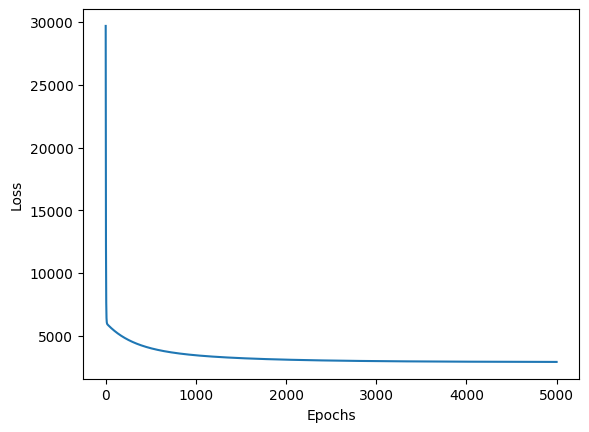

In [ ]:
model.plot_loss()

### Stochastic GD

#### Using SKlearn

In [ ]:
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split

x,y = load_diabetes(return_X_y=True)
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

reg = SGDRegressor(max_iter=10000)
reg.fit(x_train, y_train)
y_pred = reg.predict(x_test)
r2_score(y_test, y_pred) * 100

45.9161837793881

In [ ]:
reg.coef_, reg.intercept_

(array([  47.22148843, -163.11239904,  458.40102855,  300.7234853 ,
         -46.7461    ,  -93.85649451, -206.33257943,  144.6591435 ,
         343.44513498,  131.63204122]),
 array([151.48805666]))

#### From Scratch

In [ ]:
class SGDRegressor:
  def __init__(self):
    self.coef_ = 0.0
    self.intercept_ = 0.0
    self.loss = []

  def fit(self, x_train, y_train, epochs=100, learning_rate=0.01):
    self.coef_ = np.ones(x_train.shape[1])
    for i in range(epochs):
      epoch_losses = []
      for j in range(x_train.shape[0]):
        idx = np.random.randint(0, x_train.shape[0])

        y_hat = np.dot(x_train[idx], self.coef_) + self.intercept_

        slope_b = -2 * (y_train[idx] - y_hat)
        self.intercept_ = self.intercept_ - learning_rate * slope_b
        self.coef_ = self.coef_ - (learning_rate * slope_b * x_train[idx])
        epoch_losses.append((y_train[idx] - y_hat)**2)
      self.loss.append(np.mean(epoch_losses))
    print(f"b: {self.intercept_}, m: {self.coef_}")


  def predict(self, x_train):
    return np.dot(x_train,self.coef_) + self.intercept_


  def plot_loss(self):
    plt.plot(self.loss)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()


Pro Tip: If you want to ensure that your model use every row then you should follow these steps:
1. First make a list of all number till the last row.
2. Shuffle them.
3. Ensure your modle use those shuffled rows one by one for GD.

In [ ]:
model = SGDRegressor()
model.fit(x_train, y_train, epochs=100)

b: 163.41300110285937, m: [  52.84594846 -174.84509186  468.57185901  312.26982916  -52.70571062
  -97.10000453 -208.89520901  147.28600236  343.61962737  133.09309555]


In [ ]:
y_pred = model.predict(x_test)
r2_score(y_test, y_pred) * 100

44.504644236154114

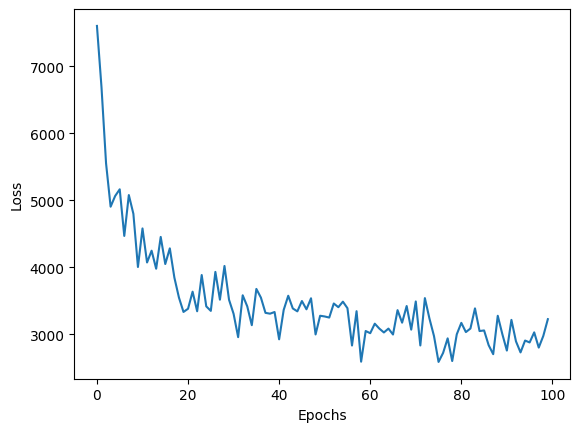

In [ ]:
model.plot_loss()

#### Time comparison between batch and Stochastic GD

In [ ]:
import time

In [ ]:
start = time.time()
model = GDRegressor2()
model.fit(x_train, y_train, epochs=500, learning_rate=0.1)
print(f"\n")
print(f"Time taken by batch GD: {time.time() - start}")

print(f"\n")
start2 = time.time()
model2 = SGDRegressor()
model2.fit(x_train, y_train, epochs=500, learning_rate=0.1)
print(f"\n")
print(f"Time taken by SGD: {time.time() - start2}")


b: 152.77769508207302, m: [ 44.44283953 -13.45423272 169.50736773 124.31159247  34.69279008
  20.16368744 -97.83196491 101.11730667 147.63714066  97.52232382]


Time taken by batch GD: 0.0743570327758789


b: 171.31067699180429, m: [  43.35788711 -265.24331355  551.9851914   329.95973464 -529.20867553
  166.68803611  -27.37413831  210.88035439  595.37898937   62.19539091]


Time taken by SGD: 4.664971113204956


SGD is slower than batch GD.

Note: SGD require less epochs to get the best result so overall time for it reduces.


In [ ]:
start = time.time()
model = GDRegressor2()
model.fit(x_train, y_train, epochs=2000, learning_rate=0.3)
print(f"\n")
print(f"Time taken by batch GD: {time.time() - start}")

print(f"\n")
start2 = time.time()
model2 = SGDRegressor()
model2.fit(x_train, y_train, epochs=50, learning_rate=0.1)
print(f"\n")
print(f"Time taken by SGD: {time.time() - start2}")


b: 151.339274619032, m: [  40.27255385 -216.64438798  525.36812817  331.40736125  -79.34530229
 -125.35929492 -217.49172921  145.07785207  387.82003183  100.46886027]


Time taken by batch GD: 0.07261800765991211


b: 146.23123647866075, m: [  26.76601607 -261.87562142  584.25656808  350.37753691 -129.02644524
 -105.51917574 -207.39677172  137.49848521  416.39718633   63.88359881]


Time taken by SGD: 0.21797704696655273


In [ ]:
y_pred1 = model.predict(x_test)
y_pred2 = model2.predict(x_test)

print(f"R2 Score of Batch GD: {r2_score(y_test, y_pred1) * 100}")
print(f"R2 Score of SGD: {r2_score(y_test, y_pred2) * 100}")

R2 Score of Batch GD: 45.818466275749024
R2 Score of SGD: 44.120062027422414


Pro Tip: A Learning Schedule (often called a Learning Rate Schedule or Learning Rate Decay) is a technique where you change the learning rate ($\eta$) during the training process instead of keeping it fixed at a single number.

### Mini-Batch Gradient Descent


#### Using SKlearn


In [ ]:
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score



model = SGDRegressor(learning_rate='constant', eta0=0.01)


batch_size = 20
epochs = 100
num_samples = x_train.shape[0]

for epoch in range(epochs):

    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    X_shuffled = x_train[indices]
    y_shuffled = y_train[indices]

    for j in range(0, num_samples, batch_size):
        start = j
        stop = min(j + batch_size, num_samples)

        X_batch = X_shuffled[start:stop]
        y_batch = y_shuffled[start:stop]

        model.partial_fit(X_batch, y_batch)


y_pred = model.predict(x_test)
print(f"Final R2 Score: {r2_score(y_test, y_pred) * 100:.2f}%")
print(f"Intercept (b): {model.intercept_[0]}")
print(f"Coefficients (m):\n{model.coef_}")

Final R2 Score: 44.63%
Intercept (b): 151.40153401073218
Coefficients (m):
[ 5.69972385e+01 -9.02775082e+01  3.59126904e+02  2.48121485e+02
  7.59718618e-02 -3.65434067e+01 -1.80891438e+02  1.47726213e+02
  2.83367985e+02  1.47259499e+02]


#### From Scratch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class GDRegressor3:
  def __init__(self):
    self.coef_ = 0.0
    self.intercept_ = 0.0
    self.loss = []

  def fit(self, x_train, y_train, epochs=100, learning_rate=0.01, batch_size=None):
    if batch_size is None:
      batch_size = x_train.shape[0]

    self.coef_ = np.ones(x_train.shape[1])
    num_samples = x_train.shape[0]
    num_batches = int(np.ceil(num_samples / batch_size))

    for i in range(epochs):
      epoch_losses = []
      permutation = np.random.permutation(num_samples)
      x_shuffled = x_train[permutation]
      y_shuffled = y_train[permutation]

      for j in range(num_batches):
        start_idx = j * batch_size
        end_idx = min((j + 1) * batch_size, num_samples)

        x_batch = x_shuffled[start_idx:end_idx]
        y_batch = y_shuffled[start_idx:end_idx]
        n_batch = x_batch.shape[0]

        y_hat = np.dot(x_batch, self.coef_) + self.intercept_
        residuals = y_batch - y_hat

        slope_b = -2 * np.mean(residuals)
        slope_m = -2 * np.dot(residuals, x_batch) / n_batch

        self.intercept_ = self.intercept_ - learning_rate * slope_b
        self.coef_ = self.coef_ - (learning_rate * slope_m)

        epoch_losses.append(np.mean(residuals**2))

      self.loss.append(np.mean(epoch_losses))

    print(f"b: {self.intercept_}, m: {self.coef_}")


  def predict(self, x_test):
    return np.dot(x_test, self.coef_) + self.intercept_


  def plot_loss(self):
    plt.plot(self.loss)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()



In [ ]:
model = GDRegressor3()
model.fit(x_train, y_train, epochs=1000, batch_size=20)

b: 151.3673973470881, m: [  57.67036979  -93.7152562   367.08785305  252.92403465   -2.09674823
  -39.35014581 -182.89868224  149.34247449  288.61323002  148.87614911]


In [ ]:
y_pred = model.predict(x_test)
r2_score(y_test,y_pred) * 100

44.76764934395552

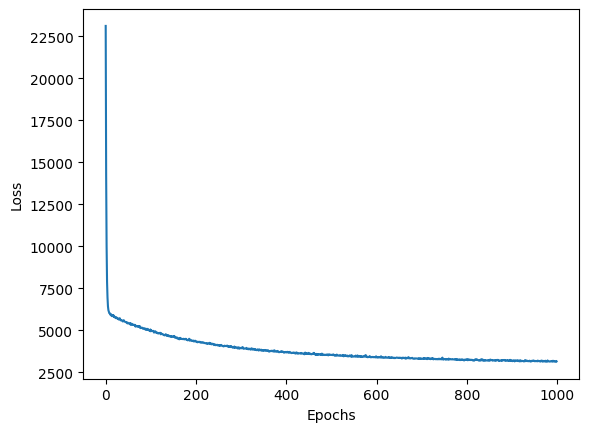

In [ ]:
model.plot_loss()

#### Comparison

In [ ]:
bgd = GDRegressor2()

start_bgd = time.time()
bgd.fit(x_train, y_train, epochs=500, learning_rate=0.1)
print(f"Time taken by Batch GD: {time.time() - start_bgd}")
print(f"\n")

sgd = SGDRegressor()

start_sgd = time.time()
sgd.fit(x_train, y_train, epochs=500, learning_rate=0.1)
print(f"Time taken by SGD: {time.time() - start_sgd}")
print(f"\n")

mbgd = GDRegressor3()

start_mbgd = time.time()
mbgd.fit(x_train, y_train, epochs=500, learning_rate=0.1, batch_size=32)
print(f"Time taken by Mini-Batch GD: {time.time() - start_mbgd}")

b: 152.77769508207302, m: [ 44.44283953 -13.45423272 169.50736773 124.31159247  34.69279008
  20.16368744 -97.83196491 101.11730667 147.63714066  97.52232382]
Time taken by Batch GD: 0.04199624061584473


b: 153.48768031856514, m: [  25.23807196 -269.98640284  560.72208269  303.81630977 -505.37866687
  197.17424453  -33.47364359  214.53625216  622.14706721   38.51744147]
Time taken by SGD: 3.4528605937957764


b: 151.43081529532878, m: [  38.70359104 -219.99070556  532.44579269  331.41845     -78.04856537
 -125.87751474 -209.79218154  143.33920795  386.53751865   95.08073714]
Time taken by Mini-Batch GD: 0.32153987884521484


In [ ]:
y_pred_bgd = bgd.predict(x_test)
y_pred_sgd = sgd.predict(x_test)
y_pred_mbgd = mbgd.predict(x_test)

print(f"R2 Score of Batch GD: {r2_score(y_test, y_pred_bgd) * 100}")
print(f"R2 Score of SGD: {r2_score(y_test, y_pred_sgd) * 100}")
print(f"R2 Score of Mini-Batch GD: {r2_score(y_test, y_pred_mbgd) * 100}")

R2 Score of Batch GD: 33.90919916025725
R2 Score of SGD: 46.68503267225786
R2 Score of Mini-Batch GD: 45.899121914892525


## Polynomial Linear Regression

- For 3 input and one output:
$$y = b_0 + \underbrace{b_1x_1 + b_2x_2 + b_3x_3}_{\text{Linear Terms}} + \underbrace{b_4x_1^2 + b_5x_2^2 + b_6x_3^2}_{\text{Squared Terms}} + \underbrace{b_7(x_1x_2) + b_8(x_1x_3) + b_9(x_2x_3)}_{\text{Interaction Terms}}$$

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
x = 6 * np.random.rand(200,1) - 3
y = 0.8 + x**2 + 0.9 *x +2 + np.random.randn(200,1)
x.shape, y.shape

((200, 1), (200, 1))

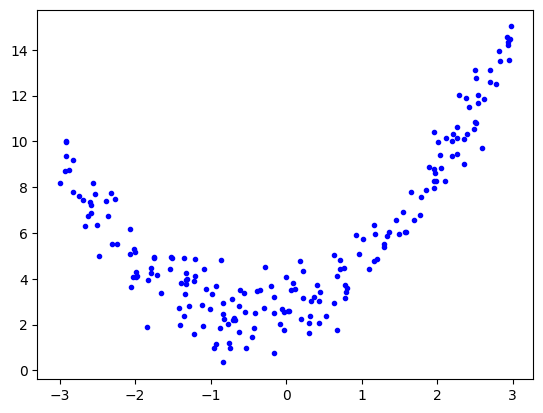

In [ ]:
plt.plot(x,y, 'b.')

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
r2_score(y_test, y_pred) * 100

13.898135303263103

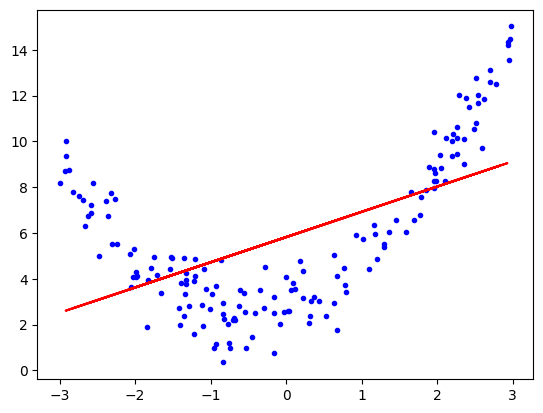

In [ ]:
plt.plot(x_train, y_train, 'b.')
plt.plot(x_test, y_pred, 'r')

In [ ]:
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)

In [ ]:
x_train_poly[0] # x^0, x^1, x^2

array([ 1.        , -2.68713673,  7.22070383])

In [ ]:
lr = LinearRegression()
lr.fit(x_train_poly, y_train)
y_pred = lr.predict(x_test_poly)
r2_score(y_test, y_pred) * 100

95.23312749568143

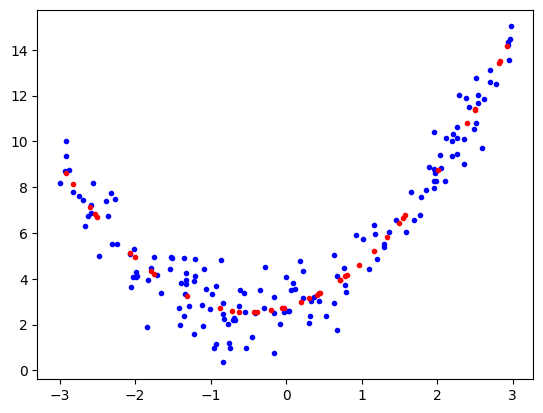

In [ ]:
plt.plot(x_train, y_train, 'b.')
plt.plot(x_test, y_pred, 'r.')

## Bias Variance Trade-off

- Bias: Bias represents the inability of a machine learning model to capture the true underlying relationship in the data, often resulting in high error on both training and test sets. High bias models are typically too simple.

- Variance: Variance refers to the model's sensitivity to fluctuations in the training data. A model with high variance performs exceptionally well on training data but fails to generalize to unseen test data, indicating it has "memorized" the noise in the training set.

- Overfitting: Occurs when a model has low bias but high variance. It performs well on training data but performs poorly on new, unseen data.

- Underfitting: Occurs when a model has high bias and low variance. The model is too simple to capture the complexity of the data, leading to poor performance on both training and testing datasets.

- Avoid overfitting:
  - Regularization
  - Boosting
  - Bagging

### Regularization

Types:
  - Ridge (L2)
  - Lasso (L1)
  - ElasticNet

#### Ridge Regularization or L2 Regularization
- It adds penalty directly to the loss function.

$$\text{Cost Function} = \text{MSE} + \alpha \sum_{j=1}^{d} w_j^2$$

Where:
  - $\text{MSE}$ is your standard loss: $\frac{1}{n} \sum (y - \hat{y})^2$.
  - $w_j$ represents the weights/coefficients of your features.
  - $\alpha$ (Alpha) is the regularization strength (a hyperparameter you control).
  - $\sum_{j=1}^{d} w_j^2$ is the sum of all your squared weights (this is the L2 norm).

  $$b = \bar y - m \bar x$$

When m > 0:
$$m = \frac {\sum_{i=1}^n (y_i - \bar y) (x_i - \bar x) }{\sum_{i=1}^n (x_i - \bar x)^2 - \lambda} $$

&nbsp;


$$L = (XW-Y)^T (XW-Y) + \lambda W^TW$$

$$L = W^TX^TXW - 2W^TX^TY + Y^TY + \lambda W^TW$$

$$ W = (X^TX + \lambda I)^{-1} X^TY$$

**Key Points of L2 Regularization**
1. When we increases Lambda then how does coeffecint being affected?
    - The coeffecient shrinks to nearly zero but not equal to zero.

2. High value (m) is affected more.
3. It alter variance and bias.
4. It do changes in Loss.


#### Lasso Regularization or L1 Regularization
- It adds a penalty equal to the absolute value of the model's coefficients to the loss function.

$$\text{Cost Function} = \text{MSE} + \alpha \sum_{j=1}^{d} |w_j|$$

Where:
  - $\text{MSE}$ is your standard loss: $\frac{1}{n} \sum (y - \hat{y})^2$.
  - $w_j$ represents the weights/coefficients of your features.
  - $\alpha$ (Alpha) is the regularization strength (a hyperparameter you control).



$$b = \bar y - m \bar x$$

When m > 0:
$$m = \frac {\sum_{i=1}^n (y_i - \bar y) (x_i - \bar x) - \lambda}{\sum_{i=1}^n (x_i - \bar x)^2}$$

When m = 0:
$$m = \frac {\sum_{i=1}^n (y_i - \bar y) (x_i - \bar x)}{\sum_{i=1}^n (x_i - \bar x)^2}$$

When m < 0:
$$m = \frac {\sum_{i=1}^n (y_i - \bar y) (x_i - \bar x) + \lambda}{\sum_{i=1}^n (x_i - \bar x)^2}$$

#### Elastic Net Regularization

$$\text{Cost Function} = \text{MSE} +\alpha \sum_{j=1}^{d} |w_j|^2 +  \beta \sum_{j=1}^{d} |w_j|$$

Where:
  - $\text{MSE}$ is your standard loss: $\frac{1}{n} \sum (y - \hat{y})^2$.
  - $w_j$ represents the weights/coefficients of your features.


